In [1]:
print("Here begins the baseline models notebook.")

Here begins the baseline models notebook.


In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
df_ml = pd.read_csv("../../data/processed/mental_health_tech_ml.csv")

df_ml.head()

,Age,self_employed,family_history,treatment,remote_work,tech_company,obs_consequence,Age__missing,Gender__missing,state__missing,self_employed__missing,work_interfere__missing,Gender_male,Country_Austria,"Country_Bahamas, The",Country_Belgium,Country_Bosnia and Herzegovina,Country_Brazil,Country_Bulgaria,Country_Canada,Country_China,Country_Colombia,Country_Costa Rica,Country_Croatia,Country_Czech Republic,Country_Denmark,Country_Finland,Country_France,Country_Georgia,Country_Germany,Country_Greece,Country_Hungary,Country_India,Country_Ireland,Country_Israel,Country_Italy,Country_Japan,Country_Latvia,Country_Mexico,Country_Moldova,Country_Netherlands,Country_New Zealand,Country_Nigeria,Country_Norway,Country_Philippines,Country_Poland,Country_Portugal,Country_Romania,Country_Russia,Country_Singapore,Country_Slovenia,Country_South Africa,Country_Spain,Country_Sweden,Country_Switzerland,Country_Thailand,Country_United Kingdom,Country_United States,Country_Uruguay,Country_Zimbabwe,state_AZ,state_CA,state_CO,state_CT,state_DC,state_FL,state_GA,state_IA,state_ID,state_IL,state_IN,state_KS,state_KY,state_LA,state_MA,state_MD,state_ME,state_MI,state_MN,state_MO,state_MS,state_NC,state_NE,state_NH,state_NJ,state_NM,state_NV,state_NY,state_OH,state_OK,state_OR,state_PA,state_RI,state_SC,state_SD,state_TN,state_TX,state_UT,state_VA,state_VT,state_WA,state_WI,state_WV,state_WY,work_interfere_Often,work_interfere_Rarely,work_interfere_Sometimes,no_employees_100-500,no_employees_26-100,no_employees_500-1000,no_employees_6-25,no_employees_More than 1000,benefits_No,benefits_Yes,care_options_Not sure,care_options_Yes,wellness_program_No,wellness_program_Yes,seek_help_No,seek_help_Yes,anonymity_No,anonymity_Yes,leave_Somewhat difficult,leave_Somewhat easy,leave_Very difficult,leave_Very easy,mental_health_consequence_No,mental_health_consequence_Yes,phys_health_consequence_No,phys_health_consequence_Yes,coworkers_Some of them,coworkers_Yes,supervisor_Some of them,supervisor_Yes,mental_health_interview_No,mental_health_interview_Yes,phys_health_interview_No,phys_health_interview_Yes,mental_vs_physical_No,mental_vs_physical_Yes
0,37.0,0.0,0,1,0,1,0,0,0,0,1,0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,True,False,True,False,False,True,False,True,False,True,False,False,True,False,True,False,True,False,False,True,True,False,False,False,False,True
1,44.0,0.0,0,0,0,0,0,0,0,0,1,0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False
2,32.0,0.0,0,0,0,1,0,0,0,1,1,0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fal

In [4]:
# Target variable: work interference + treatment
# Create a binary target variable for work interference
# 0 --> no interference, 1 --> interference (rarely/sometimes/often)
df = df_ml.copy()

df["work_interfere_binary"] = (
    df[[
        "work_interfere_Often",
        "work_interfere_Rarely",
        "work_interfere_Sometimes"
    ]].sum(axis=1) > 0
).astype(int)

In [5]:
# Create a combined target variable with three classes:
# 0 --> no interference, 1 --> interference but no treatment, 2 --> interference
df["combined_target"] = None

# No interference
df.loc[df["work_interfere_binary"] == 0, "combined_target"] = 0

# Interference but no treatment
df.loc[
    (df["work_interfere_binary"] == 1) &
    (df["treatment"] == 0),
    "combined_target"
] = 1

# Interference + treatment
df.loc[
    (df["work_interfere_binary"] == 1) &
    (df["treatment"] == 1),
    "combined_target"
] = 2

df["combined_target"] = df["combined_target"].astype(int)

In [6]:
# Drop target variables
X = df.drop(columns=[
    "combined_target",
    "treatment",
    "work_interfere_Often",
    "work_interfere_Rarely",
    "work_interfere_Sometimes",
    "work_interfere__missing",
    "work_interfere_binary"
])

y = df["combined_target"]

In [7]:
# Result means:
# 17% employees have no work interference (class 0), meaning they do not experience mental health issues that interfere with work.
# 83% employees have work interference (class 1 + class 2)
# 35% employees experience work interference but do not seek treatment (class 1)
df["combined_target"].value_counts(normalize=True)

combined_target
2    0.482129
1    0.348689
0    0.169182
Name: proportion, dtype: float64

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

logreg = LogisticRegression(
    solver="lbfgs",
    max_iter=3000,
    class_weight="balanced",
    random_state=42
)

logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)



              precision    recall  f1-score   support

           0       0.23      0.44      0.31        43
           1       0.52      0.41      0.46        88
           2       0.77      0.65      0.71       121

    accuracy                           0.53       252
   macro avg       0.51      0.50      0.49       252
weighted avg       0.59      0.53      0.55       252

Macro F1: 0.49119017279669097
Weighted F1: 0.5526390831625546


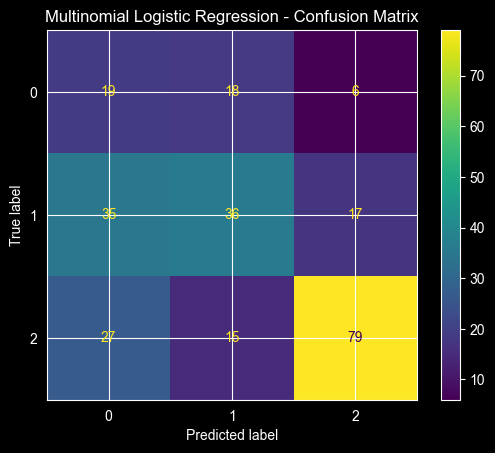

In [9]:
# Evaluation
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Classification report
print(classification_report(y_test, y_pred))

# F1-score
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print("Macro F1:", macro_f1)
print("Weighted F1:", weighted_f1)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Multinomial Logistic Regression - Confusion Matrix")
plt.show()